# 01 - Análise Exploratória de Dados (EDA)

**Projeto:** Tech Challenge Fase 1 - Pipeline de Previsão de Churn em Telecom
**Dataset:** Telco Customer Churn (IMB) - 7.043 clientes, 21 features
**Etapa:** 1 - Entedimento e Preparação

## Objetivos da EDA

1. Avaliar **Volume e qualidade** dos dados (missing, duplicados, tipos).
2. Caracterizr **distribuição** das features e da variável-alvo.
3. Identificar **questões de pré-processamento** para a etapa 2.

## 1. Setup

In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from churn_predictor.config import RAW_PATH, TARGET_COLUMN, ID_COLUMN, RANDOM_SEED

pd.set_option("display.max_columns", None)


## 2. Carga do Dataset

In [2]:
df_telco = pd.read_csv(RAW_PATH)
print(f"shape: {df_telco.shape}")
df_telco.head().T

shape: (7043, 21)


,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


** O dataset possui 7.043 linhas (clientes) e 21 colunas (features). O customerID aponta para uma identificação única do cliente. A coluna `Churn` é o target dessa análise.

## 3. Visão Geral
**Avaliando os tipos de dados e estatísticas gerais fornecidas pelo Pandas.** 

In [3]:
df_telco.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
df_telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df_telco.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Pontos de atenção ao analisar o dataset** <br>
Aparentemente não há nenhuma linha vazia, os contadores apontaram para a 7043 linhas preenchidas em todas as features. <br>
No metadados disponível em https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data, a features `SeniorCitizen`deveria ser Yes ou Not, mas aqui no dataset ficou como int64. <br>
A feature `TotalCharges` também retornou diferente do que estava no metadados, aqui o Pandas atribuiu `str`e no Kaggle havia o indicativo de que era uma coluna numérica. <br>
Os pontos observados nessa etapa serão aprofundados no item de qualidade de dados.

## 4. Qualidade dos Dados

### 4.1 Valores ausentes e duplicados

In [6]:
print("Confirmar se não há valores nulos no dataset")
df_telco.isna().sum().sort_values(ascending=False).head(20)

Confirmar se não há valores nulos no dataset


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [7]:
print("Testando se existem linhas duplicadas")
print(df_telco.duplicated().sum())

Testando se existem linhas duplicadas
0


In [8]:
print("Verificando se existem clientes duplicados na base:")
print(df_telco['customerID'].duplicated().sum())

Verificando se existem clientes duplicados na base:
0


### 4.2 Inspecionando a feature `SeniorCitizen`

In [9]:
print("Inspecionando a coluna SeniorCitizen")
print(f"\n Valores Únicos {df_telco['SeniorCitizen'].unique()}")
print(df_telco['SeniorCitizen'].value_counts())
print("\n Sem problemas com a variável, vamos assumir que o padrão aqui é booleano, ao invés de string")

Inspecionando a coluna SeniorCitizen

 Valores Únicos [0 1]
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

 Sem problemas com a variável, vamos assumir que o padrão aqui é booleano, ao invés de string


### 4.3 Inspecionando a feature `TotalCharges`

In [ ]:
print("Inspecionando a coluna TotalCharges")
print(f"\n Valores Únicos {df_telco['TotalCharges'].unique()}")
#print("Convertendo para números")
#df_telco["TotalCharges"] = df_telco["TotalCharges"].astype(float)

Inspecionando a coluna TotalCharges

 Valores Únicos <ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str
Convertendo para números


In [11]:
# A variável TotalCharges possui linhas que estão preenchdas com '', isso passou como not null, mas teremos que avaliar o comportamento dessa linha.
subset_espaco = df_telco['TotalCharges'] == " "
linhas_espaco = subset_espaco.sum()
print(f"Linhas com a coluna TotalCharges com espaço: {linhas_espaco}")

# Avaliando se as demais linhas possuem informação relevante ou apresentam alguma ausencia como a identificada
df_telco.loc[subset_espaco, ]

Linhas com a coluna TotalCharges com espaço: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


**Avaliação:** <br>
Apesar da feature `TotalCharges`estar vazia e isso ser um erro, revisando a documentação, a feature `tenure` revela que esses são os meses em que o cliente está na companhia. <br>
Dessa forma, esse conjunto de clientes são novos e ainda não tiveram tempo de realizar o pagamento. <br>
Podemos tratar essa variável de duas formas, ou simplesmente dropamos as linhas e perdemos aproximadamente 0,15% do dataset. Ou podemos substituir as aspas por zero, aparentemente as demais variáveis não apresentaram nenhuma violação de domínio.


### 4.4 Inspecionando o Target - `Churn`

In [12]:
quantd = df_telco[TARGET_COLUMN].value_counts()
proporcao = df_telco[TARGET_COLUMN].value_counts(normalize=True)

print("Distribuição absoluta:")
print(quantd)
print("\nProporção:")
print(proporcao.round(4))

Distribuição absoluta:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporção:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


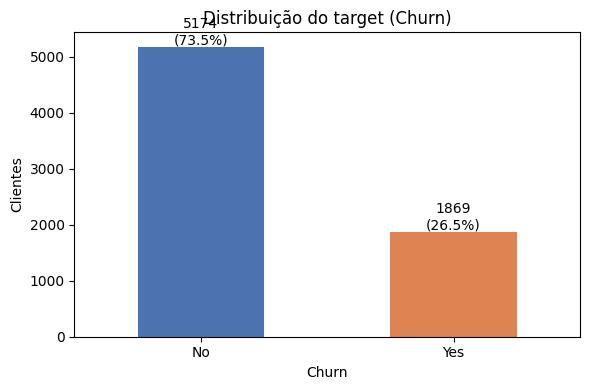

In [13]:
# Plot
fig, ax = plt.subplots(figsize=(6, 4))
quantd.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_title("Distribuição do target (Churn)")
ax.set_xlabel("Churn")
ax.set_ylabel("Clientes")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(quantd.values):
    ax.text(i, v + 50, f"{v}\n({proporcao.iloc[i]*100:.1f}%)",
            ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Desbalanceamento:** <br>
Quase `74,5%` da base tem No para o Target, com isso apenas `26,5%` temos Yes para o Churn. <br>
Nessa etapa não parece ser necessário nenhuma ação, mas é preciso tomar cuidado escolher a métrica de avaliação do modelo.

### 4.5 Inspecionando as features numéricas

**Avaliando como as features:** `tenure`, `MonthlyCharges` e `TotalCharges` estão distribuídas, além de avaliar possívies relações com a variável Churn

In [14]:
# Copia de segurança das variáveis numéricas, nesse ponto optou-se por manter as 11 linhas de TotalCharges e alterar seu conteúdo
df_num = df_telco.copy()
df_num["TotalCharges"] = df_num["TotalCharges"].replace(" ", "0").astype(float)

numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
df_num[numericas].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


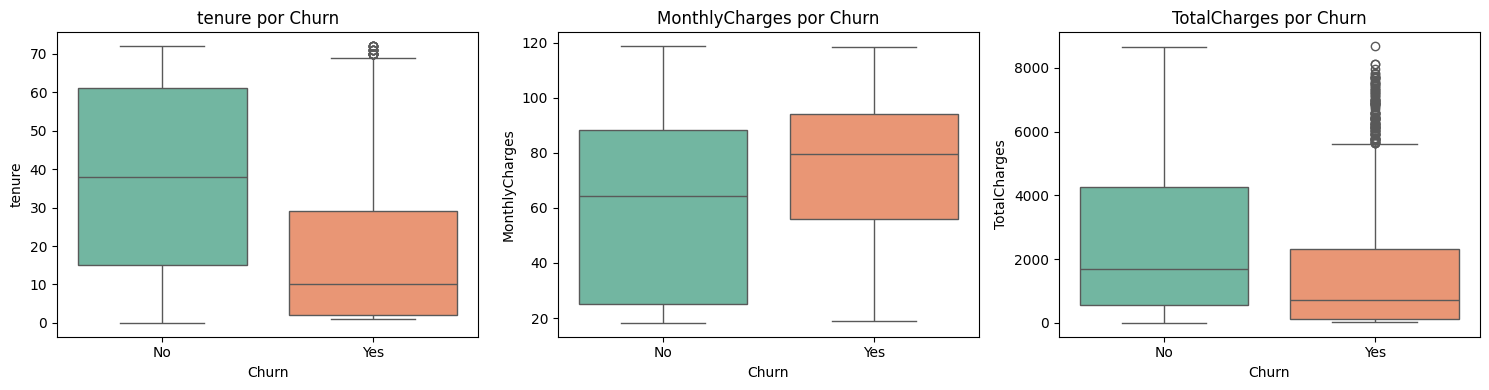

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numericas):
    sns.boxplot(data=df_num, x=TARGET_COLUMN, y=col,
                hue=TARGET_COLUMN, palette="Set2", ax=ax, legend=False)
    ax.set_title(f"{col} por {TARGET_COLUMN}")
plt.tight_layout()
plt.show()

In [17]:
#Média e medianas por classe
df_num.groupby(TARGET_COLUMN)[numericas].agg(["mean", "median"]).round(2)

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

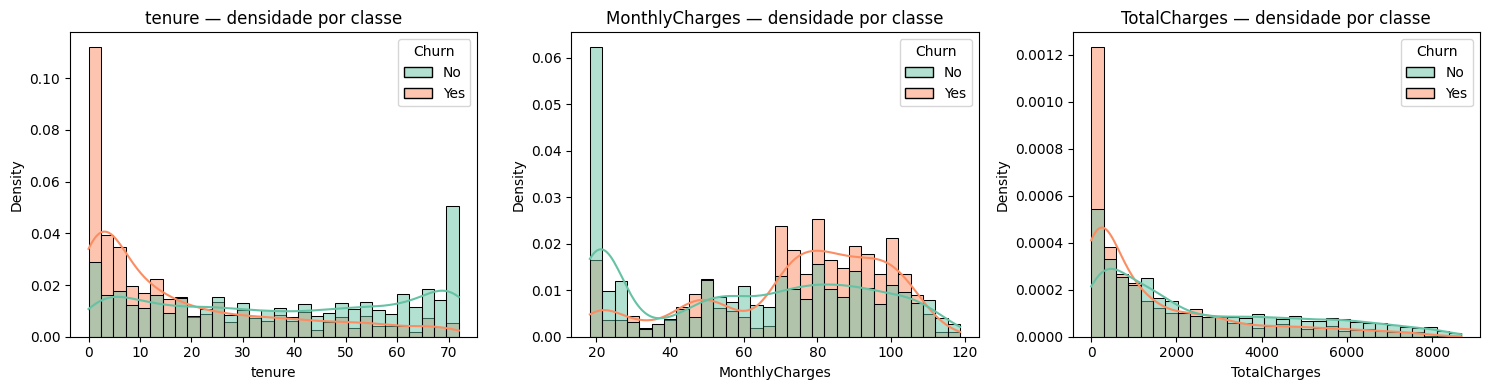

In [21]:
# histograma sobrepostos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numericas):
    sns.histplot(
        data=df_num, x=col, hue=TARGET_COLUMN,
        stat="density",          # eixo Y = densidade, não contagem
        common_norm=False,       # cada classe normalizada separadamente
        kde=True,                # adiciona a curva KDE suavizada
        bins=30,
        palette="Set2",
        alpha=0.5,
        ax=ax,
    )
    ax.set_title(f"{col} — densidade por classe")
plt.tight_layout()
plt.show()

In [19]:
# Verificar a hipotese: o pico em R$20 e cliente so-telefone?
df_num.groupby("InternetService")["MonthlyCharges"].agg(["count", "mean", "median", "std"]).round(2)

,count,mean,median,std
InternetService,,,,
DSL,2421,58.10,56.15,16.26
Fiber optic,3096,91.50,91.68,12.66
No,1526,21.08,20.15,2.16


In [20]:
# Churn rate por grupo de InternetService
df_num.groupby("InternetService")[TARGET_COLUMN].value_counts(normalize=True).unstack().round(3) * 100

Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


**Constatações:** <br>
- `tenure` parace ser a variável mais forte entre as analisadas. Os clientes Churn-Yes tem mediana de 10 meses, enquanto os Churn-Not tem por volta de 38 meses. A distribuição de churn está bem concentrada nos primeiro meses, clientes saem cedo ou ficam.
- `MonthlyCharges` mais alto correlaciona com churn. Mediana R$ 79,65 para Churn-Yes contra R$ 64,43 para Churn-Not. É possível inferir que quem está pagando mais caro, pode pensar em ir para a concorrência.
- `TotalCharges` tem correlação com `tenure` (acumulado de cobranças). Churners têm `TotalCharges` baixo principalmente porque ficam pouco tempo, não porque pagam pouco.

**Hipótese para modelagem:** essas três numéricas, sozinhas, já levam um modelo simples a um patamar razoável. `tenure × MonthlyCharges` provavelmente é um produto interessante (capacidade de captura para a MLP).

### 4.6.1 Inspecionando as features numéricas - Correlações

In [22]:
# Binarizar o target para entrar na matriz como numerica auxiliar
df_corr = df_num.copy()
df_corr["churn_bin"] = (df_corr[TARGET_COLUMN] == "Yes").astype(int)

cols_corr = numericas + ["churn_bin"]
corr_matrix = df_corr[cols_corr].corr(method="pearson").round(3)
corr_matrix

,tenure,MonthlyCharges,TotalCharges,churn_bin
tenure,1.000,0.248,0.826,-0.352
MonthlyCharges,0.248,1.000,0.651,0.193
TotalCharges,0.826,0.651,1.000,-0.198
churn_bin,-0.352,0.193,-0.198,1.000


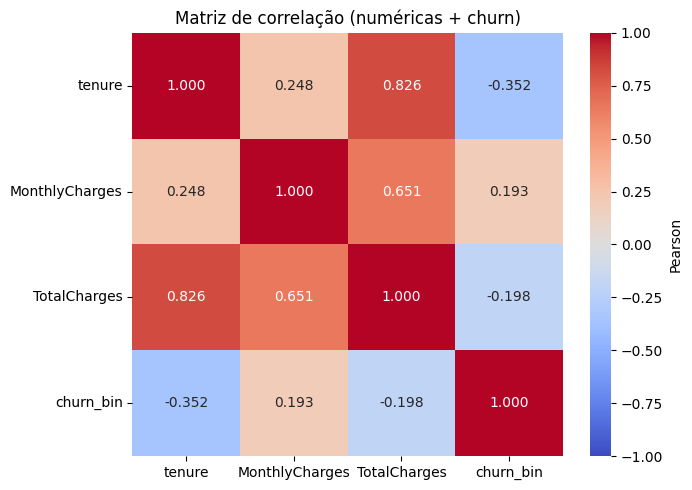

In [23]:
# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Pearson"})
ax.set_title("Matriz de correlação (numéricas + churn)")
plt.tight_layout()
plt.show()

In [24]:
# Correção com Churn e ordenada
print("Correlacao com churn (ordenada):")
corr_matrix["churn_bin"].drop("churn_bin").sort_values(key=abs, ascending=False)

Correlacao com churn (ordenada):


tenure           -0.352
TotalCharges     -0.198
MonthlyCharges    0.193
Name: churn_bin, dtype: float64

**Constatações:**

- **`tenure` × `TotalCharges` correlação ~0,83**: alta, esperada (TotalCharges = acumulado de cobranças mensais, função direta de tenure × MonthlyCharges). É **multicolinearidade**, e isso pode ser um problema com Regressões Logísticas.
- **`tenure` é possívelmente a variável com maior poder de previsão** de churn entre as numéricas: correlação ~ -0,35 com `churn_bin` (sinal negativo: mais tempo de contrato → menos churn).
- **`MonthlyCharges` correlação ~+0.19** com churn: positiva (cobrança mensal alta → mais churn). Faz sentido.
- **`TotalCharges` correlação fraca direta**, ~ -0.20, mas é uma função das outras duas — não traz informação independente.

**Implicação:**
- Para Regressão Logística: possivelmente a feature `TotalCharges` será removida.
- Para árvores e MLP: sem alterações.